# 06 - Robustness and targeted attack

In this notebook we remove stations in different fixed orders and measure how quickly the graph fragments. The targeted orders use degree, weighted degree, PageRank, betweenness, or articulation points first; the baseline removes random stations and averages several seeded trials. After each removal level we record the largest connected component (LCC), which tells us how many surviving stops remain mutually reachable in this unweighted topological model.

**Question for this notebook:** *Does choosing stations by network importance fragment the graph faster than random loss, and which ranking produces the most damage over the first 3,000 removals?*

**Input**
- The undirected trip-adjacency graph produced in notebook `02_graph_construction` (`outputs/nb/02_graph_construction/...`): a station-level graph where an edge `u - v` means there's a trip serving `v` right after `u`, weighted by the number of trips using that segment. **Required.**
- Optional: `stop_metrics.csv` from notebook 04 and `articulation_points.csv` from notebook 03. If either is unavailable, we recompute the needed ranking from the loaded graph.

**Output** (all under `outputs/nb/06_robustness_analysis/`)
- `tables/disruption_results.csv` - the full simulation grid: strategy, k removed, LCC size, **and both** normalizations of the LCC's share.
- `tables/ap_dedup_check.csv` - a diagnostic showing why the articulation-first order must contain unique station IDs.
- `tables/damage_snapshots.csv` - the LCC's share for each strategy at a few interesting values of k.
- `tables/auc_summary.csv` - the average LCC share across the simulated range for each removal strategy.
- `figures/resilience_curves_dual.png`, `figures/damage_at_k50_bar.png`, `figures/auc_comparison.png`.

Two implementation details need special care before we run the simulation: every x-axis value must correspond to that many distinct removed stations, and LCC share needs a denominator that separates planned deletion from additional fragmentation.

## Setting up the environment

We begin with the shared environment helper. It installs only missing imports, searches upward for the GTFS data folder, or clones the project into `/content` for a fresh Colab session. It then changes to the repository root and defines `REPO`, `DATA`, and `OUT`, which anchor the files used below.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## Imports, tunable constants, and the step's output folder

This cell imports pandas, NumPy, NetworkX, and Matplotlib; creates the stage folders; and collects the settings that control simulation depth and cost:

| Constant | Meaning | Cost |
|---|---|---|
| `MAX_REMOVALS = 3000` | deepest simulated removal, about 10% of the graph | larger values extend every strategy |
| `STEPS = 40` | evenly spaced points on each curve | one component scan per strategy and point |
| `EXTRA_KS` | explicit small-removal anchors | adds four early evaluations |
| `RANDOM_TRIALS = 5` | seeded permutations averaged for random failure | multiplies baseline evaluations |
| `BETWEENNESS_SAMPLES = 300` | pivots used only if no saved betweenness exists | about 300 shortest-path traversals |

With these defaults we evaluate roughly 440 graph states. Each state uses a subgraph view and a connected-components scan rather than copying the full graph, so memory stays fairly flat; runtime is usually a few minutes. `SEED` keeps fallback betweenness and random trials reproducible, while `SNAPSHOT_K` selects the small-removal bar chart.

The NumPy trapezoid alias keeps the AUC calculation compatible across NumPy versions. All generated files stay inside `outputs/nb/06_robustness_analysis`.

In [2]:
_ensure('pandas', 'numpy', 'networkx', 'matplotlib')

import pickle, random, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

# ---------------- tunables: all runtime cost lives here ----------------
MAX_REMOVALS = 3000          # deepest attack: ~10% of the network
STEPS = 40                   # evenly spaced points from 0 to MAX_REMOVALS
EXTRA_KS = [10, 25, 50, 100] # small-k anchors so the early curve is resolved
RANDOM_TRIALS = 5            # seeded trials averaged for the random baseline
SEED = 42
BETWEENNESS_SAMPLES = 300    # only used if centrality has to be recomputed here
SNAPSHOT_K = 50              # k used for the 'damage bar chart'

STAGE = OUT / '06_robustness_analysis'
(STAGE / 'tables').mkdir(parents=True, exist_ok=True)
(STAGE / 'figures').mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# numpy 2 renamed trapz -> trapezoid; support both.
_trapz = getattr(np, 'trapezoid', None) or np.trapz

print('stage folder :', STAGE)
print('networkx     :', nx.__version__)
print('pandas       :', pd.__version__)

stage folder : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/06_robustness_analysis
networkx     : 3.6.1
pandas       : 3.0.5


## Loading the available graph artifacts

We load the graph artifact from notebook 02 rather than stream `stop_times.txt` again. `find_stage_dir()` and `find_file()` locate the relevant stage and artifact, with two supported paths:

1. If an undirected graph pickle is present, we load it. A directed pickle is projected by summing opposite-direction weights.
2. Otherwise, we rebuild an undirected graph from `edges.csv`, summing rows for the same unordered pair, and attach names/regions/metros from `nodes.csv` when available.

The cell stops if neither graph representation exists. It normalizes all node IDs to strings and all edge weights to floats, then prints graph size, component count, and initial LCC share. Those baseline values tell us what `k = 0` should look like in every simulation curve.

In [3]:
def find_stage_dir(*keywords):
    """First sub-folder of OUT whose name contains one of the keywords (case-insensitive)."""
    if not OUT.exists():
        return None
    for kw in keywords:
        for d in sorted(p for p in OUT.iterdir() if p.is_dir()):
            if kw in d.name.lower():
                return d
    return None


def find_file(root, *patterns):
    """First file under `root` matching one of the glob patterns, searched recursively."""
    if root is None or not root.exists():
        return None
    for pat in patterns:
        hits = sorted(root.rglob(pat))
        if hits:
            return hits[0]
    return None


def _pick(columns, options):
    for o in options:
        if o in columns:
            return o
    return None


def to_undirected_sum(D):
    """Collapse a directed graph into an undirected one, summing both directions' weights."""
    U = nx.Graph()
    U.add_nodes_from(D.nodes(data=True))
    for u, v, data in D.edges(data=True):
        w = float(data.get('weight', 1))
        if u == v:
            continue
        if U.has_edge(u, v):
            U[u][v]['weight'] += w
        else:
            U.add_edge(u, v, weight=w)
    return U


def graph_from_csv(edges_csv, nodes_csv=None):
    """Rebuild the undirected, trip-frequency weighted graph from the stage-02 CSV exports."""
    e = pd.read_csv(edges_csv, dtype=str, encoding='utf-8-sig')
    cols = list(e.columns)
    cu = _pick(cols, ['from_stop', 'source', 'from', 'u', 'from_stop_id'])
    cv = _pick(cols, ['to_stop', 'target', 'to', 'v', 'to_stop_id'])
    cw = _pick(cols, ['trip_frequency', 'weight', 'trips', 'count'])
    if cu is None or cv is None:
        cu, cv = cols[0], cols[1]
    us = e[cu].astype(str).tolist()
    vs = e[cv].astype(str).tolist()
    ws = (pd.to_numeric(e[cw], errors='coerce').fillna(1.0).tolist()
          if cw is not None else [1.0] * len(us))

    G = nx.Graph()
    for a, b, w in zip(us, vs, ws):
        if a == b:
            continue
        if G.has_edge(a, b):
            G[a][b]['weight'] += float(w)
        else:
            G.add_edge(a, b, weight=float(w))

    if nodes_csv is not None and Path(nodes_csv).exists():
        n = pd.read_csv(nodes_csv, dtype=str, encoding='utf-8-sig')
        if 'stop_id' in n.columns:
            n = n.set_index(n['stop_id'].astype(str))
            for nid in G.nodes():
                if nid in n.index:
                    row = n.loc[nid]
                    if isinstance(row, pd.DataFrame):
                        row = row.iloc[0]
                    G.nodes[nid].update({k: row.get(k, '') for k in
                                         ['stop_name', 'region', 'metro'] if k in n.columns})
    return G


GRAPH_STAGE = find_stage_dir('graph_construction', 'graph')

graph_pkl = find_file(GRAPH_STAGE, '*undirected*.pkl', 'graph*.pkl', '*.gpickle')
edges_csv = find_file(GRAPH_STAGE, 'edges.csv', '*edges*.csv')

if graph_pkl is not None:
    with open(graph_pkl, 'rb') as f:
        _g = pickle.load(f)
    G = to_undirected_sum(_g) if _g.is_directed() else _g
    GRAPH_SOURCE = graph_pkl
elif edges_csv is not None:
    G = graph_from_csv(edges_csv, find_file(GRAPH_STAGE, 'nodes.csv', '*nodes*.csv'))
    GRAPH_SOURCE = edges_csv
else:
    raise FileNotFoundError(
        'No graph artifact found under ' + str(OUT) + '. Expected a stage folder such as '
        "outputs/nb/02_graph_construction containing graph_undirected.pkl or edges.csv - "
        'run notebook 02_graph_construction first.')

# Normalise node ids to strings and make sure every edge carries a numeric weight.
if any(not isinstance(n, str) for n in G.nodes()):
    G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()})
for _, _, d in G.edges(data=True):
    d['weight'] = float(d.get('weight', 1.0))

N0 = G.number_of_nodes()
components = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
print('graph source        :', GRAPH_SOURCE)
print('nodes / edges       :', format(N0, ','), '/', format(G.number_of_edges(), ','))
print('connected components:', len(components))
print('largest component   :', format(components[0], ','),
      '(' + str(round(100 * components[0] / N0, 2)) + '% of all stations)')

graph source        : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/graph_undirected.pkl
nodes / edges       : 30,463 / 51,772
connected components: 12
largest component   : 30,237 (99.26% of all stations)


## Attack rankings: centrality metrics

A targeted simulation needs a complete, deterministic station order. We build four metric-based orders:

- degree: number of distinct undirected neighbors;
- weighted degree: sum of scheduled edge frequencies incident to the station;
- PageRank: recursive importance based on weighted connections;
- betweenness: sampled share of unweighted shortest paths passing through the station.

When notebook 04's metrics table is available and covers enough of this graph, we reuse its PageRank and betweenness columns. Otherwise we calculate weighted PageRank on the available undirected graph and sampled betweenness on its LCC. That fallback PageRank is not direction-aware because this notebook loads an undirected graph, so rerunning notebook 04 first is preferable when we want exact agreement with its directed ranking. Degree and weighted degree always come from `G`. Finally we reindex over `G`'s node set, fill unavailable scores with zero, attach names, and print descriptive statistics.

In [4]:
CENT_STAGE = find_stage_dir('centrality')
metrics_csv = find_file(CENT_STAGE, 'stop_metrics.csv', '*metric*.csv')

metrics = None
if metrics_csv is not None:
    m = pd.read_csv(metrics_csv, dtype=str, encoding='utf-8-sig')
    if 'approx_betweenness' in m.columns and 'betweenness' not in m.columns:
        m['betweenness'] = m['approx_betweenness']
    if 'stop_id' in m.columns and {'pagerank', 'betweenness'} <= set(m.columns):
        m['stop_id'] = m['stop_id'].astype(str)
        for c in ['pagerank', 'betweenness']:
            m[c] = pd.to_numeric(m[c], errors='coerce').fillna(0.0)
        m = m[m['stop_id'].isin(G)]
        if len(m) >= 0.5 * N0:
            metrics = m[['stop_id', 'pagerank', 'betweenness']].drop_duplicates('stop_id').copy()
            print('reusing centrality from', metrics_csv, '(' + format(len(metrics), ',') + ' stations)')

if metrics is None:
    print('centrality stage not found - computing PageRank and sampled betweenness here ...')
    t0 = time.time()
    pr = nx.pagerank(G, alpha=0.85, weight='weight')
    print('  pagerank done in', round(time.time() - t0, 1), 's')
    t0 = time.time()
    Gc = G.subgraph(max(nx.connected_components(G), key=len))
    btw = nx.betweenness_centrality(Gc, k=min(BETWEENNESS_SAMPLES, Gc.number_of_nodes()),
                                    seed=SEED, normalized=True)
    print('  sampled betweenness done in', round(time.time() - t0, 1), 's')
    metrics = pd.DataFrame({'stop_id': list(G.nodes())})
    metrics['pagerank'] = metrics['stop_id'].map(pr).fillna(0.0)
    metrics['betweenness'] = metrics['stop_id'].map(btw).fillna(0.0)

# Re-index over the graph's own nodes; degree columns always come from the graph itself.
metrics = (metrics.set_index('stop_id')
                  .reindex(list(G.nodes()))
                  .fillna(0.0)
                  .reset_index()
                  .rename(columns={'index': 'stop_id'}))
metrics['stop_id'] = metrics['stop_id'].astype(str)
metrics['degree'] = metrics['stop_id'].map(dict(G.degree())).astype(float)
metrics['weighted_degree'] = metrics['stop_id'].map(dict(G.degree(weight='weight'))).astype(float)
metrics['stop_name'] = metrics['stop_id'].map({n: G.nodes[n].get('stop_name', '') for n in G.nodes()})

print()
print('metrics table:', metrics.shape)
print(metrics[['degree', 'weighted_degree', 'pagerank', 'betweenness']].describe().round(4).to_string())

reusing centrality from /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables/stop_metrics.csv (30,463 stations)

metrics table: (30463, 6)
           degree  weighted_degree    pagerank  betweenness
count  30463.0000       30463.0000  30463.0000   30463.0000
mean       3.3990        1003.8915      0.0000       0.0004
std        2.1967        1346.6542      0.0000       0.0020
min        1.0000           1.0000      0.0000       0.0000
25%        2.0000         196.0000      0.0000       0.0000
50%        3.0000         504.0000      0.0000       0.0000
75%        4.0000        1264.0000      0.0000       0.0002
max       62.0000       21396.0000      0.0004       0.1125


## Attack ranking: articulation points

An articulation point is a node whose removal increases the number of connected components. We use the saved list from notebook 03 when available; otherwise NetworkX finds the full set with a linear-depth-first traversal. This gives us a fifth strategy that explicitly prioritizes current cut vertices of the intact graph.

The set has no natural order, so we sort articulation points by initial degree, highest first, and deduplicate it. Degree is only a tie-breaking priority here; it does not measure the size of the component that removal separates. The cell prints their share of all nodes and the first ten rows so we can see which stops begin this strategy.

In [5]:
DESC_STAGE = find_stage_dir('descriptive', 'structure')
ap_csv = find_file(DESC_STAGE, 'articulation_points.csv', '*articulation*.csv')

ap_nodes = []
if ap_csv is not None:
    a = pd.read_csv(ap_csv, dtype=str, encoding='utf-8-sig')
    if 'stop_id' in a.columns:
        ap_nodes = [s for s in a['stop_id'].astype(str).tolist() if s in G]
        print('reusing', format(len(ap_nodes), ','), 'articulation points from', ap_csv)

if not ap_nodes:
    t0 = time.time()
    ap_nodes = list(nx.articulation_points(G))
    print('computed', format(len(ap_nodes), ','), 'articulation points in',
          round(time.time() - t0, 1), 's')

deg_map = dict(G.degree())
ap_nodes = sorted(set(ap_nodes), key=lambda n: -deg_map.get(n, 0))
print('articulation points:', format(len(ap_nodes), ','),
      '=', str(round(100 * len(ap_nodes) / N0, 2)) + '% of all stations')
print()
print('top 10 articulation points by degree:')
print(metrics[metrics['stop_id'].isin(ap_nodes[:10])]
      [['stop_id', 'stop_name', 'degree', 'betweenness']]
      .sort_values('degree', ascending=False).to_string(index=False))

reusing 900 articulation points from /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/03_descriptive_analysis/tables/articulation_points.csv
articulation points: 900 = 2.95% of all stations

top 10 articulation points by degree:
stop_id                              stop_name  degree  betweenness
  41133                               מחלף חמד    62.0     0.087533
   9048                 בן גוריון/שערי ירושלים    41.0     0.040754
  10775                   גשר המיתרים/שד' הרצל    37.0     0.016613
  12975                      מחלף לה גווארדייה    34.0     0.027362
  13246                בית ספר הולץ/חיל השריון    31.0     0.022369
  13322                             המסגר/הרכב    27.0     0.001008
   9553                   גשר המיתרים/שד' הרצל    22.0     0.008427
  14355                             מחלף מורשה    20.0     0.026404
  13356                דרך קיבוץ גלויות/כביש 1    20.0     0.011147
  27623 מרכז רפואי סורוקה/אוניברסיטת בן גוריון    20.0     0.025955


## Making the removal count and LCC denominator explicit

Before simulating anything, we need the x-axis and y-axis to mean exactly what their labels say.

### Every position in an attack order must be a distinct station

The articulation-first strategy starts with all articulation points and then falls back to the overall degree order so it can continue beyond the roughly 900 cut vertices. Those lists overlap completely on the articulation nodes. If we simply concatenate them and later take `set(order[:k])`, duplicate IDs mean the first `k` positions can represent fewer than `k` removed stations.

`dedup_keep_order()` removes repeated IDs while preserving the first occurrence. We apply it after concatenation and assert that every strategy contains unique IDs and is long enough for `MAX_REMOVALS`. The diagnostic table compares distinct-prefix sizes with and without this step; it is a guard against accidentally comparing strategies at different actual removal counts.

### LCC share has two useful denominators

`|LCC| / N0` measures how much of the starting node set remains together. It falls whenever we remove nodes, even if every survivor is still connected, and its maximum after `k` removals is `(N0 - k) / N0`. This view combines planned node loss with fragmentation.

`|LCC| / (N0 - k)` measures the share of surviving nodes that remain in the largest component. It stays near the initial LCC share when removal only shrinks the network and drops when the survivors split apart. We calculate both because they answer different questions, but we use the surviving-node denominator as the cleaner fragmentation measure.

In [6]:
def dedup_keep_order(seq):
    """Remove duplicates while preserving first-occurrence order."""
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out


def order_by(col):
    """Stations sorted by a metric, highest first; ties broken by degree then id for determinism."""
    s = metrics.sort_values([col, 'degree', 'stop_id'], ascending=[False, False, True])
    return s['stop_id'].tolist()


degree_order = order_by('degree')
wdegree_order = order_by('weighted_degree')
pagerank_order = order_by('pagerank')
betweenness_order = order_by('betweenness')

ap_order_with_overlap = ap_nodes + degree_order     # the two source rankings overlap
ap_order = dedup_keep_order(ap_order_with_overlap)  # position k now represents a distinct station

# --- deduplication check: distinct stations represented by each prefix ---
check_rows = []
for k in [100, 300, 500, 900, 1000, 1500, 2000, 2500, 3000]:
    without_dedup = len(set(ap_order_with_overlap[:k]))
    after_dedup = len(set(ap_order[:k]))
    check_rows.append({'k_on_x_axis': k,
                       'distinct_without_dedup': without_dedup,
                       'distinct_after_dedup': after_dedup,
                       'shortfall_without_dedup': k - without_dedup})
ap_check = pd.DataFrame(check_rows)
ap_check.to_csv(STAGE / 'tables' / 'ap_dedup_check.csv', index=False, encoding='utf-8-sig')
print('Deduplication check - articulation-first order, distinct stations removed:')
print(ap_check.to_string(index=False))

STRATEGIES = {
    'degree': degree_order,
    'weighted degree': wdegree_order,
    'pagerank': pagerank_order,
    'betweenness': betweenness_order,
    'articulation points': ap_order,
}
for name, order in STRATEGIES.items():
    assert len(order) == len(set(order)), 'duplicate entries in strategy ' + name
    if len(order) < MAX_REMOVALS:
        raise ValueError('strategy ' + name + ' has only ' + str(len(order)) +
                         ' stations, fewer than MAX_REMOVALS=' + str(MAX_REMOVALS))
print()
print('all', len(STRATEGIES), 'attack orders are duplicate-free and long enough.')

Deduplication check - articulation-first order, distinct stations removed:
 k_on_x_axis  distinct_without_dedup  distinct_after_dedup  shortfall_without_dedup
         100                     100                   100                        0
         300                     300                   300                        0
         500                     500                   500                        0
         900                     900                   900                        0
        1000                     979                  1000                       21
        1500                    1419                  1500                       81
        2000                    1900                  2000                      100
        2500                    2377                  2500                      123
        3000                    2858                  3000                      142

all 5 attack orders are duplicate-free and long enough.


## The simulation engine

`k_grid()` combines evenly spaced removal levels with explicit early anchors at 10, 25, 50, and 100. `lcc_size()` takes a removal set, creates a read-only subgraph view over the survivors, and returns the largest remaining component size. Each call performs a connected-components scan without copying the full graph.

`simulate()` walks the same k-grid for one fixed ranking. At each point it takes the first `k` unique IDs, asserts that the set size really is `k`, and records the survivor count, raw LCC size, `LCC/N0`, and `LCC/(N0-k)`.

`simulate_random()` creates one full station permutation per seeded trial and removes progressively longer prefixes. The removal sets are therefore nested within a trial instead of being unrelated samples at each k. We average LCC sizes across trials before applying the two normalizations. This gives us the bad-luck baseline against which to compare each targeted order.

In [7]:
ALL_NODES = list(G.nodes())
NODE_SET = set(ALL_NODES)


def k_grid():
    """Evenly spaced removal counts plus a few small-k anchors, sorted and unique."""
    ks = {int(round(x)) for x in np.linspace(0, MAX_REMOVALS, STEPS)}
    ks.update(k for k in EXTRA_KS if k <= MAX_REMOVALS)
    return sorted(ks)


def lcc_size(removed):
    """Size of the largest connected component after deleting `removed` (a set of node ids)."""
    survivors = NODE_SET.difference(removed)
    if not survivors:
        return 0
    return max((len(c) for c in nx.connected_components(G.subgraph(survivors))), default=0)


def _row(strategy, k, size):
    surviving = N0 - k
    return {
        'strategy': strategy,
        'removed': k,
        'surviving_nodes': surviving,
        'lcc_size': size,
        # Starting-node denominator: planned removals and fragmentation are combined.
        'lcc_share_original': round(size / N0, 5),
        # Surviving-node denominator: fragmentation among stations still present.
        'lcc_share_surviving': round(size / surviving, 5) if surviving > 0 else 0.0,
    }


def simulate(strategy, order, verbose=True):
    order = [n for n in order if n in NODE_SET]
    rows = []
    t0 = time.time()
    for k in k_grid():
        removed = set(order[:k])
        assert len(removed) == k, 'strategy ' + strategy + ' removed ' + str(len(removed)) + ' != k=' + str(k)
        rows.append(_row(strategy, k, lcc_size(removed)))
    if verbose:
        print('  ' + strategy.ljust(22), 'done in', round(time.time() - t0, 1), 's',
              '| LCC share (surviving) at k=' + str(MAX_REMOVALS) + ':',
              rows[-1]['lcc_share_surviving'])
    return pd.DataFrame(rows)


def simulate_random(trials=RANDOM_TRIALS, seed=SEED, verbose=True):
    ks = k_grid()
    sizes = {k: [] for k in ks}
    t0 = time.time()
    for t in range(trials):
        rng = random.Random(seed + t)
        perm = list(ALL_NODES)
        rng.shuffle(perm)
        for k in ks:
            sizes[k].append(lcc_size(set(perm[:k])))
    rows = [_row('random (baseline)', k, float(np.mean(sizes[k]))) for k in ks]
    if verbose:
        print('  ' + 'random (baseline)'.ljust(22), 'done in', round(time.time() - t0, 1), 's',
              '|', trials, 'seeded trials averaged')
    return pd.DataFrame(rows)


print('k-grid (' + str(len(k_grid())) + ' points):', k_grid()[:12], '...', k_grid()[-3:])

k-grid (44 points): [0, 10, 25, 50, 77, 100, 154, 231, 308, 385, 462, 538] ... [2846, 2923, 3000]


## Running the simulation

This cell runs all five fixed rankings and the averaged random baseline over the same removal grid. It concatenates the returned frames into one tidy table and saves `disruption_results.csv`, with one row per strategy and k value. This is the main runtime cost; lowering `STEPS`, `MAX_REMOVALS`, or `RANDOM_TRIALS` reduces the number of component scans. The elapsed-time messages let us see whether one strategy or the baseline dominates the cost.

In [8]:
print('simulating attacks (', len(k_grid()), 'removal levels per strategy )')
t_all = time.time()

frames = [simulate(name, order) for name, order in STRATEGIES.items()]
frames.append(simulate_random())

results = pd.concat(frames, ignore_index=True)
results.to_csv(STAGE / 'tables' / 'disruption_results.csv', index=False, encoding='utf-8-sig')

print()
print('total simulation time:', round(time.time() - t_all, 1), 's')
print('saved', STAGE / 'tables' / 'disruption_results.csv', '(' + str(len(results)), 'rows )')
print()
print(results.head(8).to_string(index=False))

simulating attacks ( 44 removal levels per strategy )
  degree                 done in 2.0 s | LCC share (surviving) at k=3000: 0.36019
  weighted degree        done in 2.0 s | LCC share (surviving) at k=3000: 0.9125
  pagerank               done in 2.1 s | LCC share (surviving) at k=3000: 0.90154
  betweenness            done in 2.0 s | LCC share (surviving) at k=3000: 0.35389
  articulation points    done in 2.1 s | LCC share (surviving) at k=3000: 0.4103
  random (baseline)      done in 10.3 s | 5 seeded trials averaged

total simulation time: 20.6 s
saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/06_robustness_analysis/tables/disruption_results.csv (264 rows )

strategy  removed  surviving_nodes  lcc_size  lcc_share_original  lcc_share_surviving
  degree        0            30463   30237.0             0.99258              0.99258
  degree       10            30453   30192.0             0.99110              0.99143
  degree       25            30438   3

## Resilience curves under both normalizations

We plot the same LCC sizes using both denominators so we can separate total retained network size from fragmentation among survivors.

- The left panel uses `|LCC| / N0`. Its dotted line is the maximum possible value `(N0-k)/N0`; the vertical gap below that ceiling is fragmentation beyond the removed nodes themselves.
- The right panel uses `|LCC| / (N0-k)`. It starts slightly below 1 because the intact graph already has small components, and it drops only when a smaller share of survivors remains in the LCC.

All strategies use the same colors and k-grid, with random failure dashed. The vertical gap from random on the right is the clearest measure of extra fragmentation caused by targeting. We save both panels together so the denominator choice remains visible.

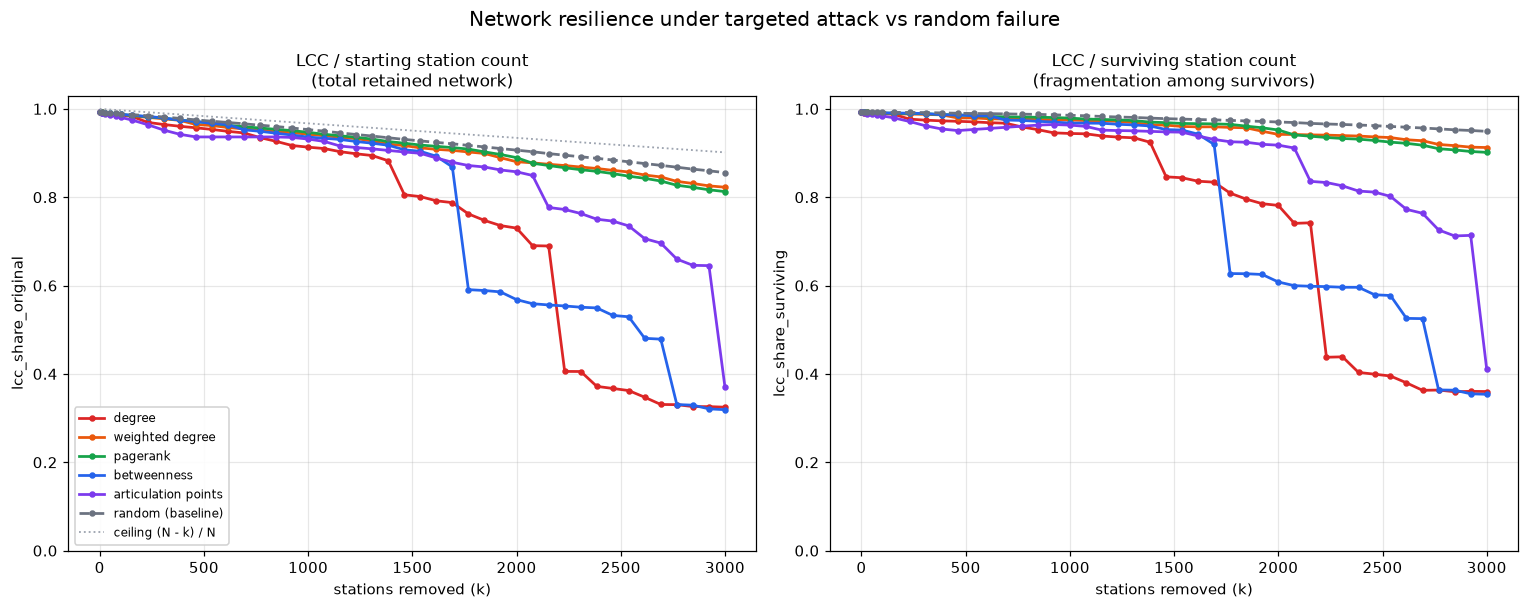

saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/06_robustness_analysis/figures/resilience_curves_dual.png


In [9]:
COLORS = {
    'degree': '#dc2626',
    'weighted degree': '#ea580c',
    'pagerank': '#16a34a',
    'betweenness': '#2563eb',
    'articulation points': '#7c3aed',
    'random (baseline)': '#6b7280',
}
STRATEGY_ORDER = list(COLORS.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharex=True)
panels = [
    ('lcc_share_original', 'LCC / starting station count\n(total retained network)'),
    ('lcc_share_surviving', 'LCC / surviving station count\n(fragmentation among survivors)'),
]

ks = np.array(k_grid(), dtype=float)
for ax, (col, title) in zip(axes, panels):
    for strat in STRATEGY_ORDER:
        g = results[results['strategy'] == strat].sort_values('removed')
        if g.empty:
            continue
        ax.plot(g['removed'], g[col], marker='o', markersize=3.2, linewidth=1.8,
                label=strat, color=COLORS[strat],
                linestyle='--' if strat == 'random (baseline)' else '-')
    if col == 'lcc_share_original':
        ax.plot(ks, (N0 - ks) / N0, color='#9ca3af', linewidth=1.2, linestyle=':',
                label='ceiling (N - k) / N')
    ax.set_xlabel('stations removed (k)')
    ax.set_ylabel(col)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 1.03)

axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)
fig.suptitle('Network resilience under targeted attack vs random failure', fontsize=13)
fig.tight_layout()
fig.savefig(STAGE / 'figures' / 'resilience_curves_dual.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved', STAGE / 'figures' / 'resilience_curves_dual.png')

## Damage snapshots at specific attack sizes

To make the curves easier to compare numerically, we extract rows at `SNAPSHOT_K`, at 500 only if that value is actually present in the k-grid, and at `MAX_REMOVALS`. With the default settings, 50 is an explicit anchor and 3,000 is the endpoint; we never substitute the nearest grid value while keeping a different label.

The saved `damage_snapshots.csv` contains both denominators for every available snapshot. The grouped chart at `SNAPSHOT_K` places `LCC/N0` beside `LCC/(N0-k)`, which shows how small the denominator difference is at 50 removals and prevents us from confusing deletion with fragmentation.

--- k = 50 (0.16% of stations removed) ---
           strategy  lcc_size  lcc_share_original  lcc_share_surviving
articulation points   30034.0             0.98592              0.98754
             degree   30130.0             0.98907              0.99069
    weighted degree   30140.0             0.98940              0.99102
        betweenness   30149.0             0.98969              0.99132
           pagerank   30161.0             0.99009              0.99171
  random (baseline)   30180.2             0.99072              0.99235

--- k = 3000 (9.85% of stations removed) ---
           strategy  lcc_size  lcc_share_original  lcc_share_surviving
        betweenness    9719.0             0.31904              0.35389
             degree    9892.0             0.32472              0.36019
articulation points   11268.0             0.36989              0.41030
           pagerank   24759.0             0.81276              0.90154
    weighted degree   25060.0             0.82264          

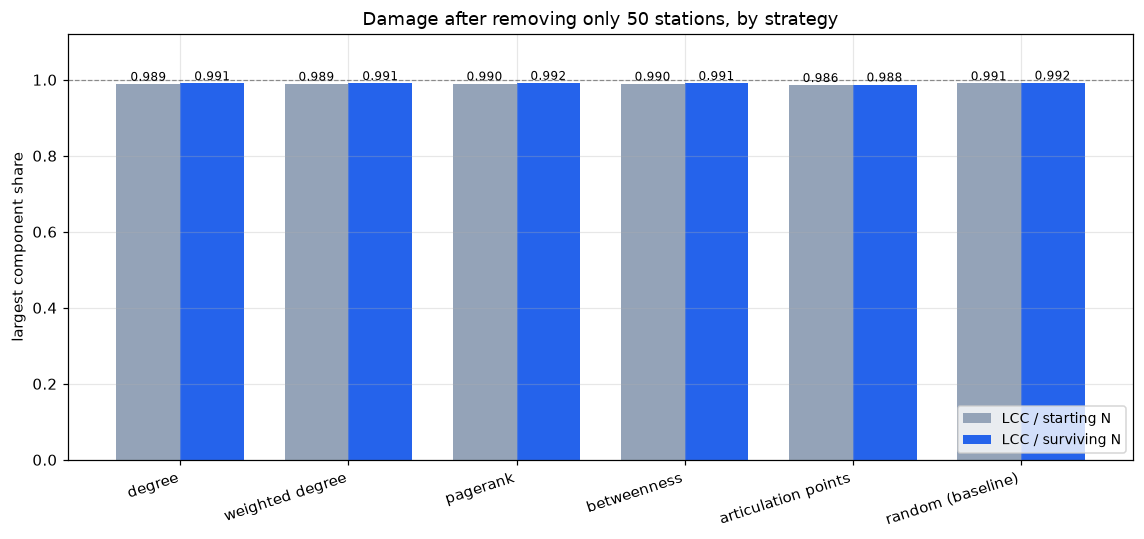

saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/06_robustness_analysis/figures/damage_at_k50_bar.png


In [10]:
snapshot_ks = [k for k in [SNAPSHOT_K, 500, MAX_REMOVALS] if k in set(k_grid())]
snapshots = (results[results['removed'].isin(snapshot_ks)]
             .sort_values(['removed', 'lcc_share_surviving'])
             .reset_index(drop=True))
snapshots.to_csv(STAGE / 'tables' / 'damage_snapshots.csv', index=False, encoding='utf-8-sig')
for k in snapshot_ks:
    print('--- k =', k, '(' + str(round(100 * k / N0, 2)) + '% of stations removed) ---')
    print(snapshots[snapshots['removed'] == k]
          [['strategy', 'lcc_size', 'lcc_share_original', 'lcc_share_surviving']]
          .to_string(index=False))
    print()

snap = (snapshots[snapshots['removed'] == SNAPSHOT_K]
        .set_index('strategy')
        .reindex([s for s in STRATEGY_ORDER])
        .dropna(subset=['lcc_size']))
x = np.arange(len(snap))
width = 0.38

fig, ax = plt.subplots(figsize=(10.5, 5))
b1 = ax.bar(x - width / 2, snap['lcc_share_original'], width,
            color='#94a3b8', label='LCC / starting N')
b2 = ax.bar(x + width / 2, snap['lcc_share_surviving'], width,
            color='#2563eb', label='LCC / surviving N')
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                format(bar.get_height(), '.3f'), ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(snap.index, rotation=18, ha='right')
ax.set_ylabel('largest component share')
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_title('Damage after removing only ' + str(SNAPSHOT_K) + ' stations, by strategy')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(STAGE / 'figures' / 'damage_at_k50_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved', STAGE / 'figures' / 'damage_at_k50_bar.png')

## One number per strategy: the area under the resilience curve

A single endpoint can miss differences in the shape of a curve, so we integrate each LCC-share series over `k = 0 ... MAX_REMOVALS` with the trapezoid rule and divide by the removal range. The result is the mean LCC share across the simulated attack depth: lower AUC means fragmentation occurs sooner or more strongly.

We calculate AUC for both denominators and rank by the surviving-node version. The denominator transformation depends on k, so the two AUC rankings are not mathematically guaranteed to match; showing them side by side tells us whether the overall ordering is sensitive to the chosen interpretation. The table and horizontal chart save the exact values.

Average largest-component share over the attack (lower = more damaging attack):
           strategy  auc_original  auc_surviving  rank_most_damaging
             degree        0.7340         0.7655                   1
        betweenness        0.7564         0.7895                   2
articulation points        0.8546         0.8964                   3
    weighted degree        0.9122         0.9587                   4
           pagerank        0.9129         0.9594                   5
  random (baseline)        0.9283         0.9760                   6


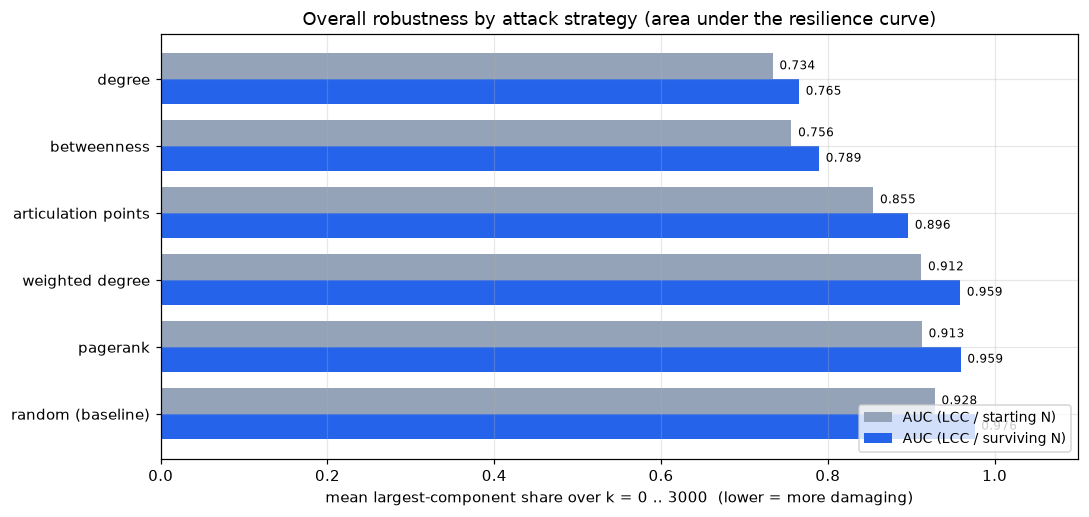

saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/06_robustness_analysis/figures/auc_comparison.png


In [11]:
auc_rows = []
for strat in STRATEGY_ORDER:
    g = results[results['strategy'] == strat].sort_values('removed')
    if g.empty:
        continue
    auc_rows.append({
        'strategy': strat,
        'auc_original': round(float(_trapz(g['lcc_share_original'], g['removed'])) / MAX_REMOVALS, 4),
        'auc_surviving': round(float(_trapz(g['lcc_share_surviving'], g['removed'])) / MAX_REMOVALS, 4),
    })
auc = pd.DataFrame(auc_rows).sort_values('auc_surviving').reset_index(drop=True)
auc['rank_most_damaging'] = np.arange(1, len(auc) + 1)
auc.to_csv(STAGE / 'tables' / 'auc_summary.csv', index=False, encoding='utf-8-sig')
print('Average largest-component share over the attack (lower = more damaging attack):')
print(auc.to_string(index=False))

y = np.arange(len(auc))
height = 0.38
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(y - height / 2, auc['auc_original'], height, color='#94a3b8', label='AUC (LCC / starting N)')
ax.barh(y + height / 2, auc['auc_surviving'], height, color='#2563eb', label='AUC (LCC / surviving N)')
for yi, (a, b) in enumerate(zip(auc['auc_original'], auc['auc_surviving'])):
    ax.text(a + 0.008, yi - height / 2, format(a, '.3f'), va='center', fontsize=8)
    ax.text(b + 0.008, yi + height / 2, format(b, '.3f'), va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(auc['strategy'])
ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.set_xlabel('mean largest-component share over k = 0 .. ' + str(MAX_REMOVALS) + '  (lower = more damaging)')
ax.set_title('Overall robustness by attack strategy (area under the resilience curve)')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig(STAGE / 'figures' / 'auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved', STAGE / 'figures' / 'auc_comparison.png')

## Conclusions

The current run does not show catastrophic fragmentation from only 50 removed stations. Under every strategy, at least about 98.76% of surviving nodes remain in the LCC; the articulation-first order is the most damaging at this small snapshot, while the random average remains at about 99.24%. This does not mean those failures have no local effect, only that they do not split a large share of the national graph at this scale.

The curves separate strongly by 3,000 removals. Approximate-betweenness targeting leaves about 35.39% of survivors in the LCC and degree targeting about 36.02%, compared with about 94.91% under random removal. Articulation-first leaves about 41.03%. PageRank and weighted-degree targeting are much closer to the random baseline, at about 90.15% and 91.25% respectively. In this graph, selecting topological hubs or shortest-path bridges is therefore far more damaging over a sustained removal sequence than selecting stations mainly by scheduled flow.

Across the full 0–3,000 range, degree has the lowest surviving-share AUC (`0.7655`), followed by betweenness (`0.7895`), articulation points (`0.8964`), weighted degree (`0.9587`), PageRank (`0.9594`), and random failure (`0.9760`). Degree does the most accumulated damage even though betweenness is slightly worse at the final endpoint. That difference is why we use both snapshots and AUC rather than declaring a winner from one k value.

The articulation-first curve needs a specific interpretation. It uses the roughly 900 cut vertices of the intact graph first, ordered by degree, and then continues with the remaining degree order. Once that initial cut-vertex set is exhausted, convergence toward the degree strategy is partly built into the ranking. Deduplicating the concatenated list ensures `k` always means `k` distinct removals.

The denominator comparison also matters. `LCC/N0` drops partly because removed nodes cannot remain in the component; `LCC/(N0-k)` isolates fragmentation among survivors. Random failure looks much more stable in the second view, which makes the extra damage from degree and betweenness targeting clearer.

There are four limits on this conclusion. Betweenness is sampled and its removal order inherits that noise. All rankings are calculated once on the intact graph rather than recomputed after every deletion, so this is an initial-rank attack, not an adaptive one. Five random trials give a baseline mean but not a precise uncertainty interval. Finally, LCC size measures reachability only: a surviving graph can remain connected while trips become much longer, less frequent, or operationally impossible. The result is evidence about topological fragmentation of the scheduled-service graph, not a full passenger disruption model.